## Tutorial 3: Training the neural network to solve a specific state transition networks

The dyngpt package can be used to train the given state transition networks. We will now demonstrate the code execution process using a one state transcriptional and translational model(ostt) as an illustrative example.

The system state is $s={{\left( {{s}_{\text{OFF}}},{{s}_{\text{ON}}},{{s}_{\text{P}}} \right)}^{\text{T}}}\in {{\left\{ 0,1 \right\}}}^{2}\times \mathbb{N}$ where ${{s}_{\text{OFF}}},{{s}_{\text{ON}}}$ indicate whether the promoter is in the inactivate/active state, ${{s}_{\text{P}}}$ is the number of protein molecules.  Five state transition vectors characterize ,promoter inactivating  and activating, protein production, and degradation: 
$$\Delta _{i}^{\left( 1 \right)}=-{{\delta }_{i,\text{OFF}}}+{{\delta }_{i,\text{ON}}},\Delta _{i}^{\left( 2 \right)}={{\delta }_{i,\text{OFF}}}-{{\delta }_{i,\text{ON}}},\Delta _{i}^{\left( 3 \right)}=-{{\delta }_{i,\text{P}}},\Delta _{i}^{\left( 4 \right)}=-{{\delta }_{i,\text{P}}},$$
where $ i \in \left\{ \text{OFF},\text{ON},\text{P} \right\}$ and ${{\delta }_{i,j}}$ is the Kronecker delta. The corresponding occurrence propensities depend on the current promoter state and protein count: $${{\lambda }_{1}}\left( s \right)={{\lambda }_{1}}\left( s \right)={{k}_{\text{on}}}{{s}_{\text{OFF}}}{{K}^{h}}/({{K}^{h}}+{{P}^{h}}),{{\lambda }_{2}}\left( s \right)={{k}_{\text{off}}}{{s}_{\text{ON}}},{{\lambda }_{3}}\left( s \right)={{k}_{\text{syn}}}{{s}_{\text{ON}}},{{\lambda }_{4}}\left( s \right)={{k}_{\deg }}{{s}_{\text{P}}}.$$  
In this STN, ${{\theta }_{\text{Dyn}}}=\left\{ {{k}_{\text{on}}},K,h,{{k}_{\text{off}}},{{k}_{syn}},{{k}_{\deg }} \right\}$.

### Load packages

In [1]:
import os
import torch
import json
import numpy as np
import sys
import matplotlib.pyplot as plt 
from matplotlib.gridspec import GridSpec
import yaml
root_dir = "/GPUFS/sysu_jjzhang_1/hzw/academicCode/DynGPTTest/DynGPT/"
sys.path.append(root_dir)
os.chdir(root_dir)
# import dyngpt
# from tutorials.utils_nn import *
from scripts.plots.utils_plot import *
from dyngpt.trainer_ import pre_training
from dyngpt.trainer_ import fine_tune_training

from dyngpt.dynmodels.default_model import get_default_model_config
from dyngpt.utils.util import *
from dyngpt.inferrer import inferring_observed_data

/GPUFS/sysu_jjzhang_1/hzw/academicCode/DynGPTTest/DynGPT


### Define utils fucntion

In [2]:
def load_synthetic_data(file_path,params_number=10,sample_number=3000,keep_index=[]):
    with open(file_path, 'r') as f:
        synthetic_datas = json.load(f)
    synthetic_samples_li = []
    params_li = []
    for i in range(params_number):
        prompt_prob = synthetic_datas[i]
        sample_weight = np.array(list(prompt_prob[1].values()))
        sample_weight = sample_weight/sum(sample_weight)
        samples_str = np.random.choice(list(prompt_prob[1].keys()),sample_number,p=sample_weight)
        synthetic_samples = np.array([el.split("_") for el in samples_str ]).astype(int)
        synthetic_samples_li.append(synthetic_samples)
        params_li.append(prompt_prob[0])
    if len(keep_index)>0:
        synthetic_samples_np = np.array(synthetic_samples_li)[:,:,keep_index]
    else:
        synthetic_samples_np = np.array(synthetic_samples_li)
    return synthetic_samples_np,np.array(params_li)

def plot_loss(losses):
    plt.figure(figsize=(3, 1.6))  # Set canvas size
    plt.plot(losses, color='royalblue')  # Research color scheme
    plt.xlabel('Epoch', fontsize=8)
    plt.ylabel('Loss value', fontsize=8)
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)

def plot_train_result(result_dir,figure_dir,si_j=[1,2]):
    data_dir = result_dir+"data/"
    sub_dir = "joint_prob"
    s_i,s_j = si_j 
    label_values = ["Simulation","DynGPT"]
    #load_data 
    raw_kl_val =pd.read_csv(data_dir + "kl_{}.csv".format(model_name), sep = ',') 
    # kl_val = raw_kl_val[(raw_kl_val < 0.12).all(axis=1)] 
    kl_val = raw_kl_val
    species_names = kl_val.columns
    mean_nn_val,mean_ssa_val,max_limit = read_pair_data(data_dir + "mean_nn_{}.csv".format(model_name),data_dir + "mean_ssa_{}.csv".format(model_name),species_names[0])
    mean_nn_val,mean_ssa_val = mean_nn_val.iloc[kl_val.index],mean_ssa_val.iloc[kl_val.index]
    mean_nn_max,mean_ssa_max = mean_nn_val.max(),mean_ssa_val.max()

    std_nn_val,std_ssa_val,max_limit = read_pair_data(data_dir + "std_nn_{}.csv".format(model_name),data_dir + "std_ssa_{}.csv".format(model_name),species_names[0])
    std_nn_val,std_ssa_val = std_nn_val.iloc[kl_val.index],std_ssa_val.iloc[kl_val.index]
    std_nn_max,std_ssa_max = std_nn_val.max(),std_ssa_val.max()
    
    width_mm=183
    width_inch = width_mm * 0.0393701
    height_inch = width_inch*0.5 * 0.4
    fig = plt.figure(figsize=(width_inch, height_inch),constrained_layout=True)
    # Defines the width ratio of each column
    gs = GridSpec(1, 6, width_ratios=[1, 1, 0.4,1, 1, 0.4], height_ratios=[1])
    y_ticks_li = [[],[],[],[],[],[]]

    scatter_colors = ["#f9e1d1", "#c6dae9"]
    edgecolors = ["#df592a","#489bc5"]

    plot_scatter(fig.add_subplot(gs[0]),mean_nn_val,mean_ssa_val,max(mean_nn_max[s_i],mean_ssa_max[s_i]),species_names[s_i],label_values,"Mean",y_ticks=y_ticks_li[0],latex_flag=False,color=scatter_colors[0],edgecolor=edgecolors[0])
    plot_scatter(fig.add_subplot(gs[1]),std_nn_val,std_ssa_val,max(std_nn_max[s_i],std_ssa_max[s_i]),species_names[s_i],label_values,"SD",y_ticks=y_ticks_li[1],latex_flag=False,color=scatter_colors[0],edgecolor=edgecolors[0])

    plot_boxplot(fig.add_subplot(gs[2]),kl_val,[species_names[s_i]],y_ticks=y_ticks_li[2],latex_flag=False,palette_color = [scatter_colors[0]],line_color=edgecolors[0])

    color_scatter = "#22629E"
    plot_scatter(fig.add_subplot(gs[3]),mean_nn_val,mean_ssa_val,max(mean_ssa_max[s_j],mean_ssa_max[s_j]),species_names[s_j],label_values,"Mean",y_ticks=y_ticks_li[3],latex_flag=False,color=scatter_colors[1],edgecolor=edgecolors[1])
    plot_scatter(fig.add_subplot(gs[4]),std_nn_val,std_ssa_val,max(std_nn_max[s_j],std_ssa_max[s_j]),species_names[s_j],label_values,"SD",y_ticks=y_ticks_li[4],latex_flag=False,color=scatter_colors[1],edgecolor=edgecolors[1])

    plot_boxplot(fig.add_subplot(gs[5]),kl_val,[species_names[s_j]],y_ticks=y_ticks_li[5],latex_flag=False,palette_color = [scatter_colors[1]],line_color=edgecolors[1])

    plt.tight_layout()
    # plt.savefig(figure_dir+"{}_mean_sd_prob.jpg".format(model_name),dpi=400)
    # # plt.savefig(figure_dir+"{}_Sfigure5_b.eps".format(model_type))
    # plt.savefig(figure_dir+"{}_Sfigure5_b.pdf".format(model_name))

### Define hyperparameter of neural network

In [3]:
model_name = "arl"
config_name = "config6"
config_path = "scripts/hyperparameter_tuning/config/{}/{}.yaml".format(model_name,config_name)
dataset_dir = "/GPUFS/sysu_jjzhang_1/hzw/academicCode/DynGPTTest/DynGPT/data/{}/".format(model_name)
result_dir = "tutorials/result/{}/{}/".format(model_name,config_name)
os.makedirs(result_dir,exist_ok=True)
figure_dir = "tutorials/figure/{}/{}/".format(model_name,config_name)
os.makedirs(figure_dir,exist_ok=True)

# load config
with open(config_path, "r") as f:
    config = yaml.safe_load(f)
config_dict = config["dyn_model"]
config_dict.update(config["nn_model"])
config_dict.update(config["inference"])
args = update_configuration(config_dict)

args.load_weight = False
args.weighted_sample = True
args.device = torch.device("cuda")
args.out_dir = result_dir
args.figure_dir = figure_dir
args.dataset_dir = dataset_dir
args.data_dir = dataset_dir

### Train the neural network

In [4]:
# # following code is used to pretrain DynGPT
import logging
logging.getLogger().setLevel(logging.ERROR)
import warnings
warnings.filterwarnings("ignore")
args.epochs = 1
dataset_path = dataset_dir + '{}_{}_stable.json'.format(args.model,"train")
loss_pre_train = pre_training(args,result_dir=result_dir,dataset_path=dataset_path)

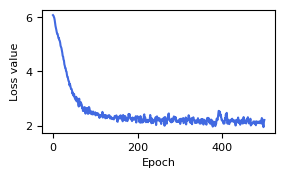

In [5]:
loss_pre_train = np.load("tutorials/result/arl/config6/train_loss/arl_epoch500.npz")["loss_mean"]
plot_loss(loss_pre_train)

In [6]:
# following code is used to fine tune DynGPT
args.start_epoch = (args.epochs//100)* 100
epoch_number = args.start_epoch 
args.epochs = 1
args.loss_type = "kl"
weight_file_path = result_dir + "weights/{}_epoch{}.pt".format(model_name,epoch_number)
dataset_path = dataset_dir + '{}_{}_stable.json'.format(args.model,"train")
loss_fine_tune = fine_tune_training(args,weight_file_path=weight_file_path,dataset_path=dataset_path)

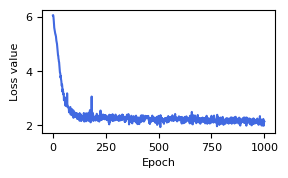

In [7]:
loss_fine_tune = np.load("tutorials/result/arl/config6/train_loss/arl_epoch1000.npz")["loss_mean"]
plot_loss(loss_fine_tune)

### Compare the stationary distribution of STN obtained by Simulation and DynGPT

the indices length is 80


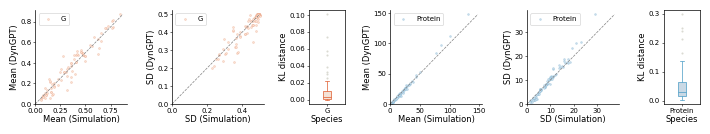

In [8]:
epoch_number = (args.epochs//100)* 100
epoch_number=2300
x_labels = args.state_name
args.valid_data_path = args.data_dir + "{}_valid_stable.json".format(model_name)
weight_path = result_dir + "weights/fine_tune_{}_epoch{}.pt".format(model_name,epoch_number)
compute_and_save_sampling_stats(args,x_labels=x_labels,weight_path=weight_path,para_index=range(80))
plot_train_result(result_dir,figure_dir,si_j=[0,1])

### Infer the stochastic dynamic from synthetic observed data

In [9]:
# the following code is for inference 
param_number = 100
args.valid_data_path = args.data_dir + "{}_valid_stable.json".format(model_name)
filtered_observed_data,true_params = load_synthetic_data(args.valid_data_path,param_number,sample_number=5000,keep_index=[])
# args.batch_size = math.ceil(filtered_observed_data.shape[1] / 1000) * 1000
prompt_prob_datasets = load_promt_prob(args,file_path=args.valid_data_path)
args.initial_value = prompt_prob_datasets[0][0][args.num_reactions:]

args.loss_type= "Hellinger" # Hellinger or Likelihood
args.loss_type= "Likelihood" # Hellinger or Likelihood
args.inference_lr = 0.0001 #0.0001 
args.weight_path = result_dir + "weights/fine_tune_{}_epoch{}.pt".format(model_name,epoch_number)
truncated_index,sample_number,iter_epoch,random_r0_number = -80,5,80,10
observed_datas, nn_sample_datas, es_params, es_loss, es_param = inferring_observed_data(filtered_observed_data,args,sample_number=sample_number,iter_epoch=iter_epoch,random_r0_number=random_r0_number,
                        model_name = model_name, figure_dir=figure_dir,result_dir=result_dir,true_params = true_params,
                        synthetic_flag=1,truncated_index=truncated_index,new_model=True)

<Figure size 640x480 with 0 Axes>

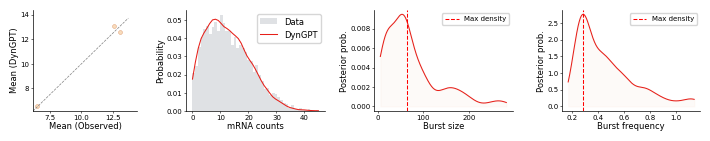

<Figure size 640x480 with 0 Axes>

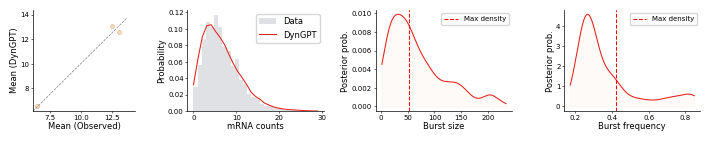

<Figure size 640x480 with 0 Axes>

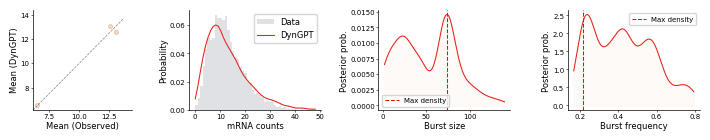

In [10]:
from dyngpt.plotting._plotting import plot_afl_inference_data_burst_distribution
import warnings
warnings.filterwarnings("ignore")
import logging
logging.getLogger().setLevel(logging.ERROR)
plot_afl_inference_data_burst_distribution(observed_datas[[0,2,3],:,1], nn_sample_datas[[0,2,3],:,:], es_params, es_loss, es_param,figure_dir=figure_dir, model_name = model_name,show_flag=True)